In [186]:
#                                                  conda activate trajectory_env

In [1]:
import time

notebook_start_time = time.time()
print("Notebook execution started...")

Notebook execution started...


In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import movingpandas as mpd
import shapely as shp
import holoviews as hv
import hvplot.pandas 
import matplotlib.pyplot as plt
from geopandas import GeoDataFrame, read_file
from shapely.geometry import Point, LineString, Polygon
from datetime import datetime, timedelta
from holoviews import opts, dim
from os.path import exists
from urllib.request import urlretrieve

import warnings
warnings.filterwarnings('ignore')

hvplot_defaults = {'line_width':5, 'frame_height':350, 'frame_width':700, 'colorbar':True, 'tiles':None, 'geo':False,}

C:\Users\ShadiNikneshan\anaconda3\envs\trajectory_env\Lib\site-packages\movingpandas\__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)


In [3]:
df= pd.read_csv(r"input.csv")

df['TS'] = df['ts'].copy()

In [4]:
df.head(5)

,classname,obj_id,classid,x,y,x2,y2,frame,ts,x_px_coord,y_px_coord,x_3d,y_3d,TS
0,car,17,0,0.947656,0.787037,0.039062,0.046296,1,2022-10-25 16:48:58,1819.49952,849.99996,57.923061,9.777832,2022-10-25 16:48:58
1,car,1,0,0.153385,0.175463,0.071354,0.095370,1,2022-10-25 16:48:58,294.49920,189.50004,-7.045120,23.337144,2022-10-25 16:48:58
2,person,2,2,0.318750,0.393519,0.021875,0.079630,1,2022-10-25 16:48:58,612.00000,425.00052,2.012347,14.973592,2022-10-25 16:48:58
3,car,4,0,0.916667,0.896759,0.067708,0.076852,1,2022-10-25 16:48:58,1760.00064,968.49972,37.292178,2.386257,2022-10-25 16:48:58
4,car,7,0,0.573698,0.611111,0.065104,0.081481,1,2022-10-25 16:48:58,1101.50016,659.99988,15.240800,10.064582,2022-10-25 16:48:58


In [5]:
# create geometry from x_3d / y_3d
df['geometry'] = [
    Point(x, y) if pd.notna(x) and pd.notna(y) else None
    for x, y in zip(df['x_3d'], df['y_3d'])]
df = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:3857')

In [6]:
tc = mpd.TrajectoryCollection(df, ['classname', 'obj_id'], t='ts', x='x_3d', y='y_3d', crs='EPSG:3857')

parked_cars = [traj for traj in tc.trajectories if traj.id[0] == 'car' and traj.get_length() < 12]
parked_tc = mpd.TrajectoryCollection(parked_cars)

moving_cars = [traj for traj in tc.trajectories if traj.id[0] == 'car' and traj.get_length() >= 12]
moving_cars_tc = mpd.TrajectoryCollection(moving_cars)

shuttle_trajectories = [traj for traj in tc.trajectories if traj.id[0] == 'shuttle']
shuttle_tc = mpd.TrajectoryCollection(shuttle_trajectories)

people_trajectories = [traj for traj in tc.trajectories if traj.df['classname'].iloc[0] == 'person']
people_tc = mpd.TrajectoryCollection(people_trajectories)

# scene analysis

In [8]:
# object dimensions (m)
SHUTTLE_LENGTH_M        = 4.75
SHUTTLE_WIDTH_M         = 2.2
PERSON_WIDTH_M          = 0.4   # lateral shoulder width
PERSON_LENGTH_M         = 0.4   # front-to-back depth
SHUTTLE_HALF_LENGTH_M   = SHUTTLE_LENGTH_M / 2
SHUTTLE_HALF_WIDTH_M    = SHUTTLE_WIDTH_M  / 2

CAR_LENGTH_M            = 4.3
CAR_WIDTH_M             = 1.8
CAR_HALF_LENGTH_M       = CAR_LENGTH_M / 2
CAR_HALF_WIDTH_M        = CAR_WIDTH_M  / 2


PERSON_HALF_WIDTH_M     = PERSON_WIDTH_M  / 2
PERSON_HALF_LENGTH_M    = PERSON_LENGTH_M / 2

# lane 
TOTAL_STREET_WIDTH_M    = 9.0
LANES_PER_DIRECTION     = 1        # number of lanes each direction
SINGLE_LANE_WIDTH_M     = 3.25     # width of one lane 
HALF_LANE_THRESHOLD_M   = SINGLE_LANE_WIDTH_M / 2

SAME_DIRECTION_MAX_LATERAL_M  = LANES_PER_DIRECTION * SINGLE_LANE_WIDTH_M

# Safety thresholds
PROXIMITY_FILTER_M      = 20.0
FORWARD_CORRIDOR_M      = 30.0
LATERAL_SAME_LANE_M     = 0.5
STOP_SPEED_MPS          = 0.5
BRAKE_ACCEL_MPS2        = 1.5

# TTC — split by agent class
CRITICAL_TTC_PERSON_SEC = 1.5   # pedestrians: standard critical threshold
WARNING_TTC_PERSON_SEC  = 3.0   # pedestrians: warning level
CRITICAL_TTC_SEC        = 3.0   # vehicles
WARNING_TTC_SEC         = 5.0   # vehicles

# PET 
PET_CRITICAL_SEC        = 1.0   # serious conflict
PET_WARNING_SEC         = 1.5   # near-miss boundary

# DRAC 
DRAC_CRITICAL_MPS2      = 2.0  
DRAC_WARNING_MPS2       = 1.0 


In [9]:
def get_agent_half_width(agent_class):
    if agent_class == 'car':
        return CAR_HALF_WIDTH_M
    elif agent_class == 'person':
        return PERSON_HALF_WIDTH_M
    return 0.0


def get_agent_half_length(agent_class):
    if agent_class == 'car':
        return CAR_HALF_LENGTH_M
    elif agent_class == 'person':
        return PERSON_HALF_LENGTH_M
    return 0.0


def _obb_half_extent_along_axis(heading_deg, half_length, half_width, axis_vec):
    """
    Project the oriented bounding box (OBB) half-extents onto an arbitrary
    axis.  Returns the scalar half-extent of the OBB shadow on that axis.
    """
    rad = np.radians(heading_deg)
    fwd = np.array([np.cos(rad), np.sin(rad)])
    right = np.array([np.sin(rad), -np.cos(rad)])
    return half_length * abs(np.dot(fwd, axis_vec)) + \
           half_width  * abs(np.dot(right, axis_vec))


def compute_body_clearance(lateral_proj, forward_proj, agent_class, shuttle_heading_deg=0.0, agent_heading_deg=None):
    
    #Compute edge-to-edge body clearance in shuttle frame (longitudinal &lateral)
    if agent_heading_deg is None:
        agent_heading_deg = shuttle_heading_deg     # same-direction default

    s_rad = np.radians(shuttle_heading_deg)
    fwd_axis   = np.array([np.cos(s_rad),  np.sin(s_rad)])
    right_axis = np.array([np.sin(s_rad), -np.cos(s_rad)])

    # Shuttle half-extents projected onto its own axes (trivially hl, hw)
    shuttle_fwd_ext  = SHUTTLE_HALF_LENGTH_M
    shuttle_lat_ext  = SHUTTLE_HALF_WIDTH_M

    # Agent half-extents projected onto shuttle's axes
    agent_hl = get_agent_half_length(agent_class)
    agent_hw = get_agent_half_width(agent_class)
    agent_fwd_ext  = _obb_half_extent_along_axis(
        agent_heading_deg, agent_hl, agent_hw, fwd_axis)
    agent_lat_ext  = _obb_half_extent_along_axis(
        agent_heading_deg, agent_hl, agent_hw, right_axis)

    longitudinal_clearance = abs(forward_proj) - shuttle_fwd_ext - agent_fwd_ext
    lateral_clearance      = abs(lateral_proj) - shuttle_lat_ext - agent_lat_ext
    return lateral_clearance, longitudinal_clearance


def get_xy(traj_or_df):
    if isinstance(traj_or_df, mpd.Trajectory):
        df = traj_or_df.df
    else:
        df = traj_or_df
    return df.geometry.x.values, df.geometry.y.values


def compute_speed_mps(df):
    x  = df.geometry.x
    y  = df.geometry.y
    dt = df.index.to_series().diff().dt.total_seconds()
    dx = x.diff()
    dy = y.diff()
    dist  = np.sqrt(dx**2 + dy**2)
    speed = dist / dt
    return speed


def compute_acceleration(speed_series, dt_series):
    return speed_series.diff() / dt_series


def angle_between_vectors(v1, v2):
    cos_a = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-9)
    cos_a = np.clip(cos_a, -1, 1)
    return np.degrees(np.arccos(cos_a))


def heading_from_dxdy(dx, dy):
    return float(np.degrees(np.arctan2(np.nanmean(dy), np.nanmean(dx))) % 360)


def get_window_df(traj, t_event, window_sec=5):
    df = traj.df
    t0 = pd.Timestamp(t_event) - pd.Timedelta(seconds=window_sec)
    t1 = pd.Timestamp(t_event) + pd.Timedelta(seconds=window_sec)
    idx = pd.DatetimeIndex(df.index)
    if idx.tz is not None:
        idx = idx.tz_localize(None)
    idx = idx.astype('datetime64[ns]')
    mask   = (idx >= t0) & (idx <= t1)
    sliced = df[mask]
    return sliced


def closest_point_on_trajectory(ref_point, other_df):
    ref  = np.array(ref_point)
    pts  = np.column_stack([other_df.geometry.x.values, other_df.geometry.y.values])
    dists = np.linalg.norm(pts - ref, axis=1)
    idx   = np.argmin(dists)
    return dists[idx], other_df.iloc[idx]


def compute_vel_vec_mps(pos_x, pos_y, time_index):
    if len(pos_x) < 2:
        return np.array([0.0, 0.0])
    dx = np.diff(pos_x)
    dy = np.diff(pos_y)
    dt = np.diff(time_index.astype(np.int64)) / 1e9  
    dt = np.where(dt == 0, np.nan, dt)
    vx = np.nanmean(dx / dt)
    vy = np.nanmean(dy / dt)
    if np.isnan(vx):
        vx = 0.0
    if np.isnan(vy):
        vy = 0.0
    return np.array([vx, vy])


def compute_edge_to_edge_dist(shuttle_pos, shuttle_heading_deg, agent_pos, agent_heading_deg, agent_class):
    """
    Compute the approximate edge-to-edge distance between shuttle and agent by subtracting the combined OBB half-extents projected onto the centroid-
    connecting axis from the centroid-to-centroid distance.
    Returns max(0, edge_gap).
    """
    rel = np.array(agent_pos) - np.array(shuttle_pos)
    cent_dist = np.linalg.norm(rel)
    if cent_dist < 1e-9:
        return 0.0
    axis = rel / cent_dist

    shuttle_ext = _obb_half_extent_along_axis(
        shuttle_heading_deg, SHUTTLE_HALF_LENGTH_M, SHUTTLE_HALF_WIDTH_M, axis)
    agent_hl = get_agent_half_length(agent_class)
    agent_hw = get_agent_half_width(agent_class)
    agent_ext = _obb_half_extent_along_axis(
        agent_heading_deg, agent_hl, agent_hw, axis)

    return max(cent_dist - shuttle_ext - agent_ext, 0.0)


In [10]:
# Relative position

def classify_relative_position(shuttle_pos, shuttle_heading_deg, other_pos):
    dx = other_pos[0] - shuttle_pos[0]
    dy = other_pos[1] - shuttle_pos[1]

    theta    = np.radians(shuttle_heading_deg)
    fwd_x,  fwd_y  =  np.cos(theta),  np.sin(theta)
    right_x, right_y = np.sin(theta), -np.cos(theta)

    forward_proj = dx * fwd_x  + dy * fwd_y
    lateral_proj = dx * right_x + dy * right_y

    if abs(forward_proj) > abs(lateral_proj) * 1.5:
        fb = 'front' if forward_proj >= 0 else 'rear'
        return fb, forward_proj, lateral_proj
    elif abs(lateral_proj) > abs(forward_proj) * 1.5:
        lr = 'right' if lateral_proj >= 0 else 'left'
        return lr, forward_proj, lateral_proj
    else:
        fb = 'front' if forward_proj >= 0 else 'rear'
        lr = 'right' if lateral_proj >= 0 else 'left'
        return f'{fb}-{lr}', forward_proj, lateral_proj

In [11]:
# CELL 12 — TTC_v1 default 
def time_to_collision(shuttle_pos, shuttle_vel, other_pos, other_vel, agent_class='car', shuttle_heading_deg=0.0, agent_heading_deg=0.0):

    rel_pos = np.array(other_pos) - np.array(shuttle_pos)
    rel_vel = np.array(other_vel) - np.array(shuttle_vel)
    dist    = np.linalg.norm(rel_pos)

    if dist > PROXIMITY_FILTER_M:
        return None

    if dist < 1e-9:
        return 0.0

    rel_pos_unit = rel_pos / dist

    # Heading-aware body-extent correction
    shuttle_ext = _obb_half_extent_along_axis(shuttle_heading_deg, SHUTTLE_HALF_LENGTH_M, SHUTTLE_HALF_WIDTH_M, rel_pos_unit)
    agent_hl = get_agent_half_length(agent_class)
    agent_hw = get_agent_half_width(agent_class)
    agent_ext = _obb_half_extent_along_axis(
        agent_heading_deg, agent_hl, agent_hw, rel_pos_unit)

    body_offset = shuttle_ext + agent_ext
    effective_dist = dist - body_offset

    if effective_dist <= 0:
        return 0.0                    # bodies already overlapping

    closing_rate = -np.dot(rel_pos_unit, rel_vel)
    if closing_rate <= 0:
        return None

    ttc = effective_dist / closing_rate

    if ttc <= 0 or ttc > 60:
        return None

    return ttc


In [12]:
# DRAC + PET_cutin  (heading-aware)
def compute_drac(rel_speed_mps, distance_m):
    if distance_m < 0.1 or rel_speed_mps <= 0:
        return None
    return (rel_speed_mps ** 2) / (2 * distance_m)


def compute_pet_cutin(forward_proj, lateral_proj, agent_spd, shuttle_spd, agent_class, shuttle_heading_deg=0.0, agent_heading_deg=None):
    # Dimension-aware PET for cut-in / overtaking
    if agent_heading_deg is None:
        agent_heading_deg = shuttle_heading_deg
    _, longit_clearance = compute_body_clearance(
        lateral_proj, forward_proj, agent_class,
        shuttle_heading_deg=shuttle_heading_deg,
        agent_heading_deg=agent_heading_deg)
    if longit_clearance <= 0.0:
        return None
    rel_spd = agent_spd - shuttle_spd
    if rel_spd < 0.1:
        return None
    return longit_clearance / rel_spd


In [13]:
# Encroachment classification 
def classify_encroachment(forward_proj, lateral_proj, agent_class,
                           heading_relation=None, crossing_angle=None,
                           forward_corridor=FORWARD_CORRIDOR_M,
                           shuttle_heading_deg=0.0, agent_heading_deg=None):
    if (heading_relation == 'crossing_paths' and crossing_angle is not None and crossing_angle > 45.0 and 0 < forward_proj <= forward_corridor):
        return 'crossing_conflict'

    if not (0 < forward_proj <= forward_corridor):
        return None

    # Agent half-width projected onto shuttle's lateral axis
    if agent_heading_deg is not None:
        s_rad = np.radians(shuttle_heading_deg)
        right_axis = np.array([np.sin(s_rad), -np.cos(s_rad)])
        agent_hl = get_agent_half_length(agent_class)
        agent_hw_proj = get_agent_half_width(agent_class)
        agent_half_w = _obb_half_extent_along_axis(
            agent_heading_deg, agent_hl, agent_hw_proj, right_axis)
    else:
        if agent_class == 'car':
            agent_half_w = CAR_HALF_WIDTH_M
        elif agent_class == 'person':
            agent_half_w = PERSON_HALF_WIDTH_M
        else:
            agent_half_w = SHUTTLE_HALF_WIDTH_M

    abs_lat = abs(lateral_proj)
    body_outer_edge = abs_lat + agent_half_w

    if LANES_PER_DIRECTION == 1:
        if body_outer_edge > SINGLE_LANE_WIDTH_M:
            return 'oncoming_lane_occupation'
        else:
            return 'same_lane_occupation'
    else:
        lanes_crossed = body_outer_edge / SINGLE_LANE_WIDTH_M
        if lanes_crossed > float(LANES_PER_DIRECTION):
            return 'oncoming_lane_occupation'
        elif lanes_crossed > 1.0:
            return 'adjacent_lane_occupation'
        else:
            return 'same_lane_occupation'


In [14]:
# Lateral safety  (heading-aware)
def compute_lateral_safety(agent_win, shuttle_win, forward_proj, lateral_proj,
                            agent_vel_vec, shuttle_vel_vec, agent_class,
                            shuttle_heading_deg=0.0, agent_heading_deg=None):
    if agent_heading_deg is None:
        agent_heading_deg = shuttle_heading_deg

    lateral_clearance, longitudinal_clearance = compute_body_clearance( lateral_proj, forward_proj, agent_class, shuttle_heading_deg=shuttle_heading_deg, 
                                                                        agent_heading_deg=agent_heading_deg)

    sx_raw = shuttle_win.geometry.x.values
    sy_raw = shuttle_win.geometry.y.values
    valid_mask = ~(np.isnan(sx_raw) | np.isnan(sy_raw))
    shuttle_win_valid_local = shuttle_win[valid_mask]
    sx_valid = shuttle_win_valid_local.geometry.x.values
    sy_valid = shuttle_win_valid_local.geometry.y.values

    common_idx = agent_win.index.intersection(shuttle_win_valid_local.index)
    lateral_closing_rate = None
    overtake_duration    = None

    if len(common_idx) > 1:
        common_int = common_idx.astype(np.int64)

        s_x = np.interp(common_int, shuttle_win_valid_local.index.astype(np.int64), sx_valid)
        s_y = np.interp(common_int, shuttle_win_valid_local.index.astype(np.int64), sy_valid)
        a_x = np.interp(common_int, agent_win.index.astype(np.int64), agent_win.geometry.x.values)
        a_y = np.interp(common_int, agent_win.index.astype(np.int64), agent_win.geometry.y.values)
        theta   = np.radians(shuttle_heading_deg)
        right_x =  np.sin(theta)
        right_y = -np.cos(theta)
        dx = a_x - s_x
        dy = a_y - s_y
        lat_signed = dx * right_x + dy * right_y

        # Use heading-aware lateral extent
        s_rad = np.radians(shuttle_heading_deg)
        right_axis = np.array([np.sin(s_rad), -np.cos(s_rad)])
        agent_hl = get_agent_half_length(agent_class)
        agent_hw_raw = get_agent_half_width(agent_class)
        agent_lat_ext = _obb_half_extent_along_axis(agent_heading_deg, agent_hl, agent_hw_raw, right_axis)

        lat_body_dists = np.abs(lat_signed) - SHUTTLE_HALF_WIDTH_M - agent_lat_ext
        lat_body_dists = np.maximum(lat_body_dists, 0.0)

        dt_arr = np.diff(pd.DatetimeIndex(common_idx).astype('datetime64[ns]').astype(np.int64)) / 1e9
        d_lat  = np.diff(lat_body_dists)
        with np.errstate(invalid='ignore', divide='ignore'):
            rates = -d_lat / (dt_arr + 1e-9)
        lateral_closing_rate = float(np.nanmean(rates))

        in_danger = lat_body_dists < 0.5
        overtake_duration = float(np.sum(dt_arr[in_danger[:-1]]))

    rel_speed = np.linalg.norm(agent_vel_vec) - np.linalg.norm(shuttle_vel_vec)

    return {
        'lateral_clearance_m'  : lateral_clearance,
        'longit_clearance_m'   : longitudinal_clearance,
        'lateral_closing_rate' : lateral_closing_rate,
        'overtake_duration_sec': overtake_duration,
        'rel_speed_mps'        : rel_speed,}


In [15]:
# TTC_v2 / PET_v2 (Hyden crossing??)
def compute_ttc_v2_crossing(shuttle_pos, shuttle_vel_vec, agent_pos, agent_vel_vec, agent_class='car'):                         
    p_s = np.array(shuttle_pos,     dtype=float)
    p_a = np.array(agent_pos,       dtype=float)
    v_s = np.array(shuttle_vel_vec, dtype=float)
    v_a = np.array(agent_vel_vec,   dtype=float)

    spd_s = np.linalg.norm(v_s)
    spd_a = np.linalg.norm(v_a)

    if spd_s < 0.1 or spd_a < 0.1:
        return None, None, None, None, None

    d_s = v_s / spd_s
    d_a = v_a / spd_a

    A   = np.array([[d_s[0], -d_a[0]], [d_s[1], -d_a[1]]])
    dp  = p_a - p_s
    det = A[0, 0] * A[1, 1] - A[0, 1] * A[1, 0]

    if abs(det) < 1e-6:
        return None, None, None, None, None

    t1 = (dp[0] * A[1, 1] - dp[1] * A[0, 1]) / det   #distance shuttle to P (m)
    t2 = (A[0, 0] * dp[1] - A[1, 0] * dp[0]) / det   #distance agent to P  (m)

    if t1 <= 0 or t2 <= 0:
        return None, None, None, None, None
    if t1 > 200 or t2 > 200:
        return None, None, None, None, None

    conflict_point = p_s + t1 * d_s
    shuttle_hl = SHUTTLE_HALF_LENGTH_M
    agent_hl   = get_agent_half_length(agent_class)

    edge_dist_shuttle = max(t1 - shuttle_hl, 0.0)                      
    edge_dist_agent   = max(t2 - agent_hl,   0.0)                      

    t_shuttle_sec = edge_dist_shuttle / spd_s                         
    t_agent_sec   = edge_dist_agent   / spd_a                          

    if t_shuttle_sec > 60 or t_agent_sec > 60:
        return None, None, None, None, None

    ttc_v2 = min(t_shuttle_sec, t_agent_sec)
    pet_v2 = abs(t_shuttle_sec - t_agent_sec)                        

    return ttc_v2, pet_v2, conflict_point, t_shuttle_sec, t_agent_sec

In [16]:
# compute_safety_metrics 

def compute_safety_metrics(
    shuttle_pos, shuttle_vel_vec, shuttle_speeds, agent_pos, agent_vel_vec, agent_speeds, dist_at_event, dist_trend, forward_proj, lateral_proj,
    shuttle_win, agent_win, t_event, agent_class, heading_relation=None, crossing_angle=None, shuttle_heading_deg=0.0, agent_heading_deg=0.0):
    shuttle_spd = float(np.nanmean(np.abs(shuttle_speeds.dropna())))
    agent_spd   = float(np.nanmean(np.abs(agent_speeds.dropna()))
                        if len(agent_speeds.dropna()) > 0 else np.nan)
    if np.isnan(agent_spd):
        agent_spd = 0.0
    rel_speed = agent_spd - shuttle_spd

    encroach_type = classify_encroachment(
        forward_proj, lateral_proj, agent_class, heading_relation=heading_relation, crossing_angle=crossing_angle, 
        shuttle_heading_deg=shuttle_heading_deg, agent_heading_deg=agent_heading_deg )
    encroach = encroach_type is not None

    is_overtaking = ( heading_relation == 'same_direction' and rel_speed > 0.5 and abs(lateral_proj) > 0.3 and forward_proj > 0)
    is_overtaking_oncoming = (is_overtaking and encroach_type == 'oncoming_lane_occupation')

    if (crossing_angle is not None and heading_relation == 'crossing_paths' and crossing_angle > 45.0):
        closing_speed = shuttle_spd * abs(np.sin(np.radians(crossing_angle)))
    elif heading_relation == 'opposite_direction':
        closing_speed = shuttle_spd + agent_spd
    else:
        closing_speed = abs(rel_speed)

    in_forward_corridor = 0 < forward_proj <= FORWARD_CORRIDOR_M

    compute_ttc_drac = (
        encroach_type in ('same_lane_occupation', 'crossing_conflict')
        or ((is_overtaking or is_overtaking_oncoming
             or encroach_type == 'adjacent_lane_occupation')
            and in_forward_corridor))
    if heading_relation == 'opposite_direction' and not is_overtaking_oncoming:
        compute_ttc_drac = False

    compute_dhw = compute_ttc_drac

    # Edge-to-edge distance (for DRAC & display)
    edge_dist = compute_edge_to_edge_dist(
        shuttle_pos, shuttle_heading_deg,
        agent_pos, agent_heading_deg, agent_class)

    # TTC_v1 
    ttc_v1 = None
    if compute_ttc_drac:
        if encroach_type == 'crossing_conflict':
            if closing_speed > 0.1:
                # Heading-aware: project agent OBB onto shuttle's forward axis
                s_rad = np.radians(shuttle_heading_deg)
                fwd_axis = np.array([np.cos(s_rad), np.sin(s_rad)])
                agent_hl = get_agent_half_length(agent_class)
                agent_hw = get_agent_half_width(agent_class)
                agent_fwd_ext = _obb_half_extent_along_axis(
                    agent_heading_deg, agent_hl, agent_hw, fwd_axis)
                edge_gap = forward_proj - SHUTTLE_HALF_LENGTH_M - agent_fwd_ext
                if edge_gap <= 0:
                    ttc_v1 = 0.0
                else:
                    ttc_raw = edge_gap / closing_speed
                    ttc_v1 = ttc_raw if 0 < ttc_raw < 60 else None

        elif (is_overtaking or is_overtaking_oncoming
              or encroach_type == 'adjacent_lane_occupation'):
            _, longit_cl = compute_body_clearance(
                lateral_proj, forward_proj, agent_class,
                shuttle_heading_deg=shuttle_heading_deg,
                agent_heading_deg=agent_heading_deg)
            if longit_cl > 0:
                longitudinal_closing = shuttle_spd - agent_spd
                ttc_a = (longit_cl / longitudinal_closing
                         if longitudinal_closing > 0.1 else None)
                if ttc_a is not None and not (0 < ttc_a < 60):
                    ttc_a = None
                ttc_b = (longit_cl / shuttle_spd
                         if shuttle_spd > 0.1 else None)
                if ttc_b is not None and not (0 < ttc_b < 60):
                    ttc_b = None
                candidates = [t for t in [ttc_a, ttc_b] if t is not None]
                ttc_v1 = min(candidates) if candidates else None
            elif longit_cl <= 0 and shuttle_spd > 0.1:
                ttc_v1 = 0.0

        else:
            ttc_v1 = time_to_collision(
                shuttle_pos, shuttle_vel_vec, agent_pos, agent_vel_vec,
                agent_class=agent_class,
                shuttle_heading_deg=shuttle_heading_deg,
                agent_heading_deg=agent_heading_deg)

    # TTC_v2 / PET_v2
    ttc_v2          = None
    pet_v2          = None
    conflict_point  = None
    t_shuttle_to_cp = None
    t_agent_to_cp   = None

    if encroach_type == 'crossing_conflict':
        ttc_v2, pet_v2, conflict_point, t_shuttle_to_cp, t_agent_to_cp = \
            compute_ttc_v2_crossing( shuttle_pos, shuttle_vel_vec, agent_pos,   agent_vel_vec, agent_class=agent_class)

    # DRAC 
    drac = None
    if compute_ttc_drac and edge_dist > 0:
        if (is_overtaking or is_overtaking_oncoming
                or encroach_type == 'adjacent_lane_occupation'):
            _, longit_cl = compute_body_clearance(
                lateral_proj, forward_proj, agent_class,
                shuttle_heading_deg=shuttle_heading_deg,
                agent_heading_deg=agent_heading_deg )
            if longit_cl > 0.1 and shuttle_spd > 0.1:
                drac = (shuttle_spd ** 2) / (2.0 * longit_cl)
        elif closing_speed > 0.1:
            drac = compute_drac(closing_speed, edge_dist)     

    # PET_cutin 
    pet_cutin = None
    if is_overtaking_oncoming or is_overtaking or encroach_type == 'adjacent_lane_occupation':
        pet_cutin = compute_pet_cutin(
            forward_proj, lateral_proj, agent_spd, shuttle_spd, agent_class,
            shuttle_heading_deg=shuttle_heading_deg,
            agent_heading_deg=agent_heading_deg)

    # DHW 
    _, longit_clearance = compute_body_clearance(
        lateral_proj, forward_proj, agent_class,
        shuttle_heading_deg=shuttle_heading_deg,
        agent_heading_deg=agent_heading_deg)
    dhw       = None
    req_decel = None
    if compute_dhw:
        dhw = max(longit_clearance, 0.0)
        if shuttle_spd > 0.1 and dhw > 0.1:
            req_decel = (shuttle_spd ** 2) / (2.0 * dhw)

    # Lateral safety 
    lateral_safety = None
    compute_lateral = (
        encroach_type in ('oncoming_lane_occupation', 'adjacent_lane_occupation',
                           'same_lane_occupation', 'crossing_conflict')
        and not (heading_relation == 'opposite_direction'
                 and not is_overtaking_oncoming))
    if compute_lateral:
        lateral_safety = compute_lateral_safety(
            agent_win, shuttle_win, forward_proj, lateral_proj,
            agent_vel_vec, shuttle_vel_vec, agent_class,
            shuttle_heading_deg=shuttle_heading_deg,
            agent_heading_deg=agent_heading_deg)

    return {
        'ttc_v1_sec'            : ttc_v1,
        'ttc_v2_sec'            : ttc_v2,
        'pet_v2_sec'            : pet_v2,
        'conflict_point'        : conflict_point,
        't_shuttle_to_cp_sec'   : t_shuttle_to_cp,
        't_agent_to_cp_sec'     : t_agent_to_cp,
        'drac_mps2'             : drac,
        'pet_cutin_sec'         : pet_cutin,
        'dhw_m'                 : dhw,
        'req_decel_mps2'        : req_decel,
        'lane_encroachment'     : encroach,
        'encroach_type'         : encroach_type,
        'lateral_safety'        : lateral_safety,
        'rel_speed_mps'         : rel_speed,
        'closing_speed_mps'     : closing_speed,
        'is_overtaking'         : is_overtaking,
        'is_overtaking_oncoming': is_overtaking_oncoming,
        'edge_to_edge_dist_m'   : edge_dist,
    }


In [17]:
# Speed classification
def describe_speed_event(speeds, stopped_thresh=0.5, change_thresh=1.5, decel_thresh=-1.5, hard_decel_thresh=-3.0):
    if speeds is None or len(speeds.dropna()) < 2:
        return 'unknown'

    s = speeds.dropna()
    mean_spd = s.mean()
    min_spd  = s.min()
    max_spd  = s.max()

    step_accels = s.diff().dropna()

    was_stopped = min_spd < stopped_thresh
    was_moving  = max_spd > stopped_thresh * 2

    if was_stopped and was_moving:
        return 'stopped_then_moving'
    if mean_spd < stopped_thresh:
        return 'stopped'
    if step_accels.min() < hard_decel_thresh:
        return 'hard_braking'

    n     = len(s)
    chunk = max(1, min(3, n // 3))
    spd_start = s.iloc[:chunk].mean()
    spd_end   = s.iloc[-chunk:].mean()
    delta     = spd_end - spd_start

    if delta < -change_thresh:
        return 'braking'
    if delta > change_thresh:
        return 'accelerating'

    return 'moving_steady'


In [18]:
def _generate_narrative(
    agent_class, obj_id, rel_pos, forward_proj, lateral_proj,
    dist_at_event, min_dist,
    dist_trend, heading_relation, crossing_angle,
    agent_speed_mean, shuttle_speed_mean,
    speed_delta, agent_speed_state, agent_min_accel,
    ttc_v1, ttc_v2, pet_v2, pet_cutin, drac, dhw, req_decel,
    encroach_type, lateral_safety,
    agent_heading, shuttle_heading):
    parts = []

    parts.append(
        f"{agent_class.capitalize()} #{obj_id} is {dist_at_event:.1f}m "
        f"{rel_pos} of shuttle "
        f"(fwd={forward_proj:.1f}m, lat={lateral_proj:+.1f}m)")

    if encroach_type == 'same_lane_occupation':
        parts.append("DIRECTLY IN SHUTTLE LANE")
    elif encroach_type == 'crossing_conflict':
        angle_str = (f" at {crossing_angle:.0f}°"
                     if crossing_angle is not None else "")
        ped_label = " (pedestrian crossing)" if agent_class == 'person' else ""
        parts.append(f"CROSSING SHUTTLE PATH{angle_str} {ped_label}")
        if crossing_angle is not None:
            parts.append(f"crossing angle {crossing_angle:.1f}°")
    elif encroach_type == 'oncoming_lane_occupation':
        if LANES_PER_DIRECTION == 1:
            parts.append(
                "in ONCOMING LANE "
                "(1-lane road: no same-direction overtaking lane exists)"
            )
        else:
            parts.append("CROSSED INTO ONCOMING LANE")
        if heading_relation == 'same_direction' and speed_delta > 0.5:
            parts.append("OVERTAKING the shuttle")
    elif encroach_type == 'adjacent_lane_occupation':
        parts.append(
            f"in adjacent lane (lane 2 of {LANES_PER_DIRECTION} "
            f"same-direction lanes)"
        )
        if speed_delta > 0.5:
            parts.append("OVERTAKING the shuttle")
    elif heading_relation == 'opposite_direction':
        parts.append("moving in OPPOSITE direction (head-on geometry)")

    if dist_trend == 'approaching':
        parts.append("gap still closing")
    elif dist_trend == 'receding':
        parts.append("gap opening (conflict resolving)")

    if agent_speed_state == 'hard_braking':
        parts.append("agent hard braking")
    elif agent_speed_state == 'braking':
        parts.append("agent braking")
    elif agent_speed_state == 'accelerating':
        parts.append("agent accelerating")
    elif agent_speed_state == 'stopped_then_moving':
        parts.append("agent stopped then moving")

    if ttc_v1 is not None:
        _ttc_crit = CRITICAL_TTC_PERSON_SEC if agent_class == 'person' else CRITICAL_TTC_SEC
        _ttc_warn = WARNING_TTC_PERSON_SEC  if agent_class == 'person' else WARNING_TTC_SEC
        if ttc_v1 < _ttc_crit:
            parts.append(f"TTC_v1={ttc_v1:.1f}s CRITICAL (<{_ttc_crit}s)")
        elif ttc_v1 < _ttc_warn:
            parts.append(f"TTC_v1={ttc_v1:.1f}s WARNING (<{_ttc_warn}s)")
        else:
            parts.append(f"TTC_v1={ttc_v1:.1f}s")

    if ttc_v2 is not None:
        _ttc_crit = CRITICAL_TTC_PERSON_SEC if agent_class == 'person' else CRITICAL_TTC_SEC
        _ttc_warn = WARNING_TTC_PERSON_SEC  if agent_class == 'person' else WARNING_TTC_SEC
        if ttc_v2 < _ttc_crit:
            parts.append(f"TTC_v2={ttc_v2:.1f}s CRITICAL (<{_ttc_crit}s)")
        elif ttc_v2 < _ttc_warn:
            parts.append(f"TTC_v2={ttc_v2:.1f}s WARNING (<{_ttc_warn}s)")
        else:
            parts.append(f"TTC_v2={ttc_v2:.1f}s")

    if pet_v2 is not None:
        if pet_v2 < PET_CRITICAL_SEC:
            parts.append(
                f"PET_v2={pet_v2:.1f}s CRITICAL "
                f"near-miss (<{PET_CRITICAL_SEC}s)")
        elif pet_v2 < PET_WARNING_SEC:
            parts.append(
                f"PET_v2={pet_v2:.1f}s near-miss "
                f"(<{PET_WARNING_SEC}s)"
            )
        else:
            parts.append(f"PET_v2={pet_v2:.1f}s")

    if pet_cutin is not None:
        if pet_cutin < PET_CRITICAL_SEC:
            parts.append(
                f"PET_cutin={pet_cutin:.2f}s CRITICAL cut-in "
                f"(<{PET_CRITICAL_SEC}s)"
            )
        elif pet_cutin < PET_WARNING_SEC:
            parts.append(
                f"PET_cutin={pet_cutin:.2f}s near-miss cut-in "
                f"(<{PET_WARNING_SEC}s)"
            )
        else:
            parts.append(f"PET_cutin={pet_cutin:.2f}s")

    if drac is not None:
        if drac > DRAC_CRITICAL_MPS2:
            parts.append(
                f"DRAC={drac:.2f} m/s² CRITICAL (>{DRAC_CRITICAL_MPS2} m/s²)"
            )
        elif drac > DRAC_WARNING_MPS2:
            parts.append(
                f"DRAC={drac:.2f} m/s² WARNING (>{DRAC_WARNING_MPS2} m/s²)"
            )
        else:
            parts.append(f"DRAC={drac:.2f} m/s²")

    if dhw is not None:
        parts.append(f"DHW={dhw:.1f}m")

    if req_decel is not None:
        if req_decel > DRAC_CRITICAL_MPS2:
            parts.append(
                f"req decel to stop={req_decel:.2f} m/s² "
                f"(hard braking needed)"
            )
        elif req_decel > DRAC_WARNING_MPS2:
            parts.append(
                f"req decel to stop={req_decel:.2f} m/s² (firm braking)"
            )
        else:
            parts.append(f"req decel to stop={req_decel:.2f} m/s²")

    if lateral_safety is not None:
        lc = lateral_safety['lateral_clearance_m']
        if lc < 0.5:
            parts.append(f"lateral body clearance only {lc:.2f}m (UNSAFE)")
        elif lc < 1.0:
            parts.append(f"lateral clearance {lc:.2f}m (tight)")
        ot = lateral_safety.get('overtake_duration_sec')
        if ot is not None and ot > 0:
            parts.append(f"in danger zone {ot:.1f}s")

    return "; ".join(parts) + "."

In [19]:
# main _ analyze_anomaly

In [20]:
def analyze_anomaly(
    anomalous_event_ts,
    shuttle_tc,
    moving_cars_tc,
    people_tc,
    parked_tc=None,
    window_sec=5,
    origin=(0, 0)):
    t_event = pd.Timestamp(anomalous_event_ts)

    shuttle_traj = shuttle_tc.trajectories[0]
    shuttle_win  = get_window_df(shuttle_traj, t_event, window_sec)

    if shuttle_win.empty:
        print(f"[!] No shuttle data found around {t_event}")
        return None

    sx_raw = shuttle_win.geometry.x.values.astype(float)
    sy_raw = shuttle_win.geometry.y.values.astype(float)

    shuttle_valid_mask = ~(np.isnan(sx_raw) | np.isnan(sy_raw))
    shuttle_win_valid  = shuttle_win[shuttle_valid_mask]
    sx = shuttle_win_valid.geometry.x.values
    sy = shuttle_win_valid.geometry.y.values

    shuttle_speeds = compute_speed_mps(shuttle_win)
    shuttle_dt     = shuttle_win.index.to_series().diff().dt.total_seconds()
    shuttle_accel  = compute_acceleration(shuttle_speeds, shuttle_dt)

    event_idx = shuttle_win_valid.index.get_indexer([t_event], method='nearest')[0]

    if event_idx == -1 or len(sx) == 0:
        print(f"[!] No valid (non-NaN) shuttle 3D coordinates in window around {t_event}")
        return None

    shuttle_pos_at_event = (sx[event_idx], sy[event_idx])
    shuttle_spd_at_event = (shuttle_speeds.iloc[event_idx]
                            if event_idx < len(shuttle_speeds) else np.nan)

    sdx = np.diff(sx)
    sdy = np.diff(sy)
    shuttle_heading     = heading_from_dxdy(sdx, sdy)

    shuttle_vel_vec     = np.array([np.nanmean(sdx), np.nanmean(sdy)])

    shuttle_speed_event = describe_speed_event(shuttle_speeds)
    dist_shuttle_to_origin = np.linalg.norm(
        np.array(shuttle_pos_at_event) - np.array(origin)
    )

    _shuttle_px_ready = False
    if ('x_px_coord' in shuttle_win.columns and
            'y_px_coord' in shuttle_win.columns):
        _spx = shuttle_win['x_px_coord'].values.astype(float)
        _spy = shuttle_win['y_px_coord'].values.astype(float)
        _spx_mask = ~(np.isnan(_spx) | np.isnan(_spy))
        if _spx_mask.any():
            _s_px_idx = shuttle_win.index[_spx_mask].astype(np.int64)
            _s_px_x   = _spx[_spx_mask]
            _s_px_y   = _spy[_spx_mask]
            _t_event_int = pd.DatetimeIndex([t_event]).astype(np.int64)[0]
            _shuttle_px_at_event = (
                float(np.interp(_t_event_int, _s_px_idx, _s_px_x)),
                float(np.interp(_t_event_int, _s_px_idx, _s_px_y)),
            )
            _shuttle_px_ready = True

    report = {
        'event_ts'               : t_event,
        'window_sec'             : window_sec,
        'shuttle_heading'        : shuttle_heading,
        'shuttle_speed_state'    : shuttle_speed_event,
        'shuttle_pos_at_event'   : shuttle_pos_at_event,
        'shuttle_dist_to_origin' : dist_shuttle_to_origin,
        'interactions'           : []
    }

    print("=" * 70)
    print(f"ANOMALY ANALYSIS — Event timestamp: {t_event}")
    print(f"Time window: ±{window_sec}s  |  "
          f"Data available: {shuttle_win.index[0]} → {shuttle_win.index[-1]}")
    print("=" * 70)
    print(f"\n[SHUTTLE]")
    print(f"  Position at event : ({shuttle_pos_at_event[0]:.2f}, "
          f"{shuttle_pos_at_event[1]:.2f}) m from origin")
    print(f"  Distance to origin: {dist_shuttle_to_origin:.2f} m")
    print(f"  Heading           : {shuttle_heading:.1f}°")
    print(f"  Speed state       : {shuttle_speed_event}")
    print(f"  Mean speed        : {shuttle_speeds.mean():.2f} m/s  |  "
          f"Speed at event: {shuttle_spd_at_event:.2f} m/s")
    print(f"  Max deceleration  : {shuttle_accel.min():.2f} m/s²")

    all_agents = []
    for tc_group, label in [(moving_cars_tc, 'car'), (people_tc, 'person')]:
        for traj in tc_group.trajectories:
            all_agents.append((traj, label))

    print("\n" + "─" * 70)
    print("PAIRWISE INTERACTIONS WITH SHUTTLE")
    print("─" * 70)

    skipped = []

    for traj, agent_class in all_agents:
        agent_win = get_window_df(traj, t_event, window_sec)
        if agent_win.empty:
            continue

        obj_id = traj.id[1] if isinstance(traj.id, tuple) else traj.id

        ax = agent_win.geometry.x.values.astype(float)
        ay = agent_win.geometry.y.values.astype(float)
        valid = ~(np.isnan(ax) | np.isnan(ay))

        # Rebuild geometry from x_3d / y_3d if geometry is NaN
        if valid.sum() == 0 and 'x_3d' in agent_win.columns and 'y_3d' in agent_win.columns:
            x3d = agent_win['x_3d'].values.astype(float)
            y3d = agent_win['y_3d'].values.astype(float)
            valid_3d = ~(np.isnan(x3d) | np.isnan(y3d))
            if valid_3d.sum() > 0:
                from shapely.geometry import Point
                agent_win = agent_win.copy()
                agent_win['geometry'] = [
                    Point(x3d[i], y3d[i]) if valid_3d[i] else Point(float('nan'), float('nan'))
                    for i in range(len(x3d))]
                agent_win = agent_win[valid_3d]
                ax = agent_win.geometry.x.values.astype(float)
                ay = agent_win.geometry.y.values.astype(float)
                valid = ~(np.isnan(ax) | np.isnan(ay))

        if valid.sum() == 0:
            if not _shuttle_px_ready:
                skipped.append((agent_class, obj_id, -1))
                continue
            if ('x_px_coord' not in agent_win.columns or
                    'y_px_coord' not in agent_win.columns):
                skipped.append((agent_class, obj_id, -1))
                continue

            a_px_x = agent_win['x_px_coord'].values.astype(float)
            a_px_y = agent_win['y_px_coord'].values.astype(float)
            a_px_mask = ~(np.isnan(a_px_x) | np.isnan(a_px_y))
            if not a_px_mask.any():
                skipped.append((agent_class, obj_id, -1))
                continue

            ax = a_px_x
            ay = a_px_y
            valid = a_px_mask
            from shapely.geometry import Point
            agent_win = agent_win.copy()
            agent_win['geometry'] = [Point(a_px_x[i], a_px_y[i]) for i in range(len(a_px_x)) ]
            agent_win = agent_win[valid]
            ax = agent_win.geometry.x.values
            ay = agent_win.geometry.y.values

            shuttle_pos_for_agent = _shuttle_px_at_event

            s_px_x_win = np.interp(agent_win.index.astype(np.int64), _s_px_idx, _s_px_x)
            s_px_y_win = np.interp(agent_win.index.astype(np.int64), _s_px_idx, _s_px_y)

            using_pixels = True
        else:
            shuttle_pos_for_agent = shuttle_pos_at_event
            using_pixels = False

        if not valid.all() and not using_pixels:
            agent_win = agent_win[valid]
            ax = agent_win.geometry.x.values
            ay = agent_win.geometry.y.values

        single_point = len(ax) < 2

        if single_point:
            agent_speeds      = pd.Series([np.nan])
            agent_accel       = pd.Series([np.nan])
            agent_heading     = np.nan
            agent_vel_vec     = np.array([0.0, 0.0])
            agent_speed_state = 'unknown'
        else:
            agent_speeds      = compute_speed_mps(agent_win)
            agent_dt          = agent_win.index.to_series().diff().dt.total_seconds()
            agent_accel       = compute_acceleration(agent_speeds, agent_dt)
            adx               = np.diff(ax)
            ady               = np.diff(ay)
            agent_heading     = heading_from_dxdy(adx, ady)
            agent_vel_vec     = np.array([np.nanmean(adx), np.nanmean(ady)])
            agent_speed_state = describe_speed_event(agent_speeds)

        # Distances 
        if using_pixels:
            dists_px = np.sqrt((ax - s_px_x_win)**2 + (ay - s_px_y_win)**2)
            dist_at_event = float(dists_px[
                np.argmin(np.abs(
                    (agent_win.index - t_event).total_seconds()))])
            min_dist   = float(dists_px.min())
            dist_trend = ('approaching' if dists_px[-1] < dists_px[0] else 'receding')
            skip_proximity_gate = True
        else:
            common_idx = agent_win.index.intersection(shuttle_win_valid.index)
            if len(common_idx) > 0 and not single_point:
                common_int = common_idx.astype(np.int64)
                s_interp_x = np.interp(common_int,shuttle_win_valid.index.astype(np.int64), sx)
                s_interp_y = np.interp(common_int,shuttle_win_valid.index.astype(np.int64), sy)
                a_interp_x = np.interp(common_int,
                                       agent_win.index.astype(np.int64), ax)
                a_interp_y = np.interp(common_int,
                                       agent_win.index.astype(np.int64), ay)
                distances_over_time = np.sqrt(
                    (s_interp_x - a_interp_x)**2 + (s_interp_y - a_interp_y)**2
                )
                min_dist      = distances_over_time.min()
                event_i       = np.argmin(
                    np.abs((common_idx - t_event).total_seconds()))
                dist_at_event = distances_over_time[event_i]
                dist_trend    = ('approaching'
                                 if distances_over_time[-1] < distances_over_time[0]
                                 else 'receding')
            else:
                pts           = np.column_stack([ax, ay])
                dists         = np.linalg.norm(
                    pts - np.array(shuttle_pos_at_event), axis=1)
                min_dist      = float(dists.min())
                dist_at_event = float(dists.min())
                dist_trend    = 'unknown'
            skip_proximity_gate = False

        if not skip_proximity_gate:
            if np.isnan(dist_at_event) or dist_at_event > PROXIMITY_FILTER_M:
                skipped.append((agent_class, obj_id,
                                 dist_at_event if not np.isnan(dist_at_event) else -1))
                continue

        agent_event_idx = agent_win.index.get_indexer([t_event], method='nearest')[0]
        agent_event_idx = min(agent_event_idx, len(ax) - 1)
        agent_pos_at_event = (ax[agent_event_idx], ay[agent_event_idx])

        rel_pos, forward_proj, lateral_proj = classify_relative_position(
            shuttle_pos_for_agent, shuttle_heading, agent_pos_at_event )

        if np.isnan(agent_heading):
            heading_relation = 'unknown'
            crossing_angle   = None
            _agent_hdg_for_metrics = shuttle_heading  # default 
        else:
            heading_diff = abs(shuttle_heading - agent_heading) % 360
            if heading_diff > 180:
                heading_diff = 360 - heading_diff
            if heading_diff < 30:
                heading_relation = 'same_direction'
            elif heading_diff > 150:
                heading_relation = 'opposite_direction'
            else:
                heading_relation = 'crossing_paths'
            if (np.linalg.norm(shuttle_vel_vec) > 1e-6
                    and np.linalg.norm(agent_vel_vec) > 1e-6):
                crossing_angle = angle_between_vectors(shuttle_vel_vec, agent_vel_vec)
            else:
                crossing_angle = None
            _agent_hdg_for_metrics = agent_heading

        speed_delta = (agent_speeds.mean() - shuttle_speeds.mean()
                       if not np.isnan(agent_speeds.mean()) else np.nan)

        agent_angle_to_origin = float(
            np.degrees(np.arctan2(
                agent_pos_at_event[1] - origin[1],
                agent_pos_at_event[0] - origin[0])) % 360)
        agent_dist_to_origin = np.linalg.norm(
            np.array(agent_pos_at_event) - np.array(origin))

        # Safety metrics 
        safety = compute_safety_metrics(
            shuttle_pos_for_agent, shuttle_vel_vec, shuttle_speeds,
            agent_pos_at_event,    agent_vel_vec,   agent_speeds,
            dist_at_event, dist_trend, forward_proj, lateral_proj,
            shuttle_win, agent_win, t_event, agent_class,
            heading_relation=heading_relation,
            crossing_angle=crossing_angle,
            shuttle_heading_deg=shuttle_heading,
            agent_heading_deg=_agent_hdg_for_metrics
        )
        ttc_v1                 = safety['ttc_v1_sec']
        ttc_v2                 = safety['ttc_v2_sec']
        pet_v2                 = safety['pet_v2_sec']
        conflict_point         = safety['conflict_point']
        t_shuttle_to_cp        = safety['t_shuttle_to_cp_sec']
        t_agent_to_cp          = safety['t_agent_to_cp_sec']
        drac                   = safety['drac_mps2']
        pet_cutin              = safety['pet_cutin_sec']
        dhw                    = safety['dhw_m']
        req_decel              = safety['req_decel_mps2']
        encroach               = safety['lane_encroachment']
        encroach_type          = safety['encroach_type']
        lateral_safety         = safety['lateral_safety']
        is_overtaking_oncoming = safety.get('is_overtaking_oncoming', False)
        is_overtaking          = safety.get('is_overtaking', False)
        edge_dist              = safety.get('edge_to_edge_dist_m', dist_at_event)

        # Closest-approach re-computation
        closest_approach = None
        if (encroach_type is not None and not using_pixels
                and len(common_idx) > 0 and not single_point):
            min_i     = int(np.argmin(distances_over_time))
            t_closest = common_idx[min_i]

            t_closest_int = pd.DatetimeIndex([t_closest]).astype(np.int64)[0]
            s_ca_x = float(np.interp(t_closest_int,
                           shuttle_win_valid.index.astype(np.int64), sx))
            s_ca_y = float(np.interp(t_closest_int,
                           shuttle_win_valid.index.astype(np.int64), sy))
            a_ca_x = float(np.interp(t_closest_int,
                           agent_win.index.astype(np.int64), ax))
            a_ca_y = float(np.interp(t_closest_int,
                           agent_win.index.astype(np.int64), ay))

            _, fwd_ca, lat_ca = classify_relative_position(
                (s_ca_x, s_ca_y), shuttle_heading, (a_ca_x, a_ca_y))
            dist_ca = float(distances_over_time[min_i])

            # Edge-to-edge at closest approach
            edge_dist_ca = compute_edge_to_edge_dist(
                (s_ca_x, s_ca_y), shuttle_heading,
                (a_ca_x, a_ca_y), _agent_hdg_for_metrics, agent_class)

            safety_ca = compute_safety_metrics(
                (s_ca_x, s_ca_y), shuttle_vel_vec, shuttle_speeds,
                (a_ca_x, a_ca_y), agent_vel_vec,   agent_speeds,
                dist_ca, dist_trend, fwd_ca, lat_ca,
                shuttle_win, agent_win, t_closest, agent_class,
                heading_relation=heading_relation,
                crossing_angle=crossing_angle,
                shuttle_heading_deg=shuttle_heading,
                agent_heading_deg=_agent_hdg_for_metrics)
            dt_ca = abs((pd.Timestamp(t_closest) - t_event).total_seconds())
            closest_approach = {
                't_offset_sec': dt_ca,
                'dist_m'      : dist_ca,
                'edge_to_edge_m': edge_dist_ca,
                'forward_m'   : fwd_ca,
                'lateral_m'   : lat_ca,
                'ttc_v1_sec'  : safety_ca['ttc_v1_sec'],
                'ttc_v2_sec'  : safety_ca['ttc_v2_sec'],
                'pet_v2_sec'  : safety_ca['pet_v2_sec'],
                'pet_cutin_sec': safety_ca['pet_cutin_sec'],
                'drac_mps2'   : safety_ca['drac_mps2'],
                'dhw_m'       : safety_ca['dhw_m'],
                'req_decel'   : safety_ca['req_decel_mps2'],
            }

        # output ─────────────────────────────────────────────────────────
        narrative = _generate_narrative(
            agent_class, obj_id, rel_pos, forward_proj, lateral_proj,
            dist_at_event, min_dist,
            dist_trend, heading_relation, crossing_angle,
            agent_speeds.mean(), shuttle_speeds.mean(),
            speed_delta, agent_speed_state,
            agent_accel.min() if not single_point else np.nan,
            ttc_v1, ttc_v2, pet_v2, pet_cutin,
            drac, dhw, req_decel,
            encroach_type, lateral_safety,
            agent_heading, shuttle_heading
        )

        interaction = {
            'agent_class'            : agent_class,
            'obj_id'                 : obj_id,
            'pixel_fallback'         : using_pixels,
            'dist_at_event'          : dist_at_event,
            'edge_to_edge_dist_m'    : edge_dist,
            'min_dist_in_window'     : min_dist,
            'dist_trend'             : dist_trend,
            'forward_proj_m'         : forward_proj,
            'lateral_proj_m'         : lateral_proj,
            'rel_pos_to_shuttle'     : rel_pos,
            'heading_relation'       : heading_relation,
            'crossing_angle_deg'     : crossing_angle,
            'agent_heading_deg'      : agent_heading,
            'agent_speed_mean'       : agent_speeds.mean(),
            'agent_speed_state'      : agent_speed_state,
            'agent_min_accel'        : (agent_accel.min()
                                        if not single_point else np.nan),
            'speed_delta_vs_shuttle' : speed_delta,
            'ttc_v1_sec'             : ttc_v1,
            'ttc_v2_sec'             : ttc_v2,
            'pet_v2_sec'             : pet_v2,
            'conflict_point'         : conflict_point,
            't_shuttle_to_cp_sec'    : t_shuttle_to_cp,
            't_agent_to_cp_sec'      : t_agent_to_cp,
            'drac_mps2'              : drac,
            'pet_cutin_sec'          : pet_cutin,
            'dhw_m'                  : dhw,
            'req_decel_mps2'         : req_decel,
            'lane_encroachment'      : encroach,
            'encroach_type'          : encroach_type,
            'lateral_safety'         : lateral_safety,
            'agent_dist_to_origin'   : agent_dist_to_origin,
            'agent_angle_to_origin'  : agent_angle_to_origin,
            'narrative'              : narrative,
            'closest_approach'       : closest_approach,
            'edge_to_edge_ca_m'      : closest_approach['edge_to_edge_m'] if closest_approach else None,
        }
        report['interactions'].append(interaction)


        px_note   = " pixel-coord fallback (no 3D projection)" if using_pixels else ""
        spd_str   = f"{agent_speeds.mean():.2f} m/s" if not np.isnan(agent_speeds.mean()) else "N/A"
        dspd_str  = f"{speed_delta:+.2f} m/s"        if not np.isnan(speed_delta)         else "N/A"
        acc_str   = (f"{agent_accel.min():.2f} m/s²"
                     if not single_point else "N/A (single point)")
        hdg_str   = f"{agent_heading:.1f}°"           if not np.isnan(agent_heading)       else "N/A"
        dist_unit = "px" if using_pixels else "m"

        print(f"\n  [{agent_class.upper()} id={obj_id}]{px_note}"
              + (" single-point trajectory" if single_point else ""))
        print(f"    Centroid distance     : {dist_at_event:.1f} {dist_unit}  "
              f"(min in window: {min_dist:.1f} {dist_unit})")
        print(f"    Edge-to-edge distance : {edge_dist:.2f} {dist_unit}  (at event)")
        print(f"    Distance trend        : {dist_trend}")
        print(f"    Forward projection    : {forward_proj:.2f} {dist_unit}  "
              f"({'ahead' if forward_proj > 0 else 'behind'} of shuttle)")
        print(f"    Lateral projection    : {lateral_proj:+.2f} {dist_unit}  "
              f"({'right' if lateral_proj > 0 else 'left'} of centerline)")
        print(f"    Position rel. shuttle : {rel_pos}")
        print(f"    Lane encroachment     : {encroach_type if encroach_type else 'no'}")
        if lateral_safety:
            ls        = lateral_safety
            lat_c     = ls['lateral_clearance_m']
            lon_c     = ls['longit_clearance_m']
            lat_close = ls['lateral_closing_rate']
            ot_dur    = ls['overtake_duration_sec']
            rel_spd   = ls['rel_speed_mps']
            print(f"    ── Lateral safety ──────────────────────────────────")
            print(f"    Lateral clearance     : {lat_c:.2f} {dist_unit}  "
                  f"{'UNSAFE' if lat_c < 0.5 else 'ok'}")
            print(f"    Longit. clearance     : {lon_c:.2f} {dist_unit}  "
                  f"{'OVERLAP' if lon_c < 0 else 'ok'}")
            print(f"    Lateral closing rate  : "
                  f"{f'{lat_close:.2f} {dist_unit}/s  (+ = closing)' if lat_close is not None else 'N/A'}")
            print(f"    Overtake duration     : "
                  f"{f'{ot_dur:.1f} s' if ot_dur is not None else 'N/A'}")
            print(f"    Rel. speed (overtake) : {rel_spd:.2f} {dist_unit}/s")
        print(f"    Heading               : {hdg_str}  "
              f"(shuttle: {shuttle_heading:.1f}°)")
        print(f"    Heading relation      : {heading_relation}  |  "
              f"crossing angle: "
              f"{f'{crossing_angle:.1f}°' if crossing_angle is not None else 'N/A'}")
        print(f"    Speed state           : {agent_speed_state}  |  mean: {spd_str}")
        print(f"    Speed delta vs shuttle: {dspd_str}")
        print(f"    Max deceleration      : {acc_str}")

        print(f"    ── Safety metrics ──────────────────────────────────")
        print(f"    TTC_v1 (dim-aware)    : "
              f"{f'{ttc_v1:.1f} s' if ttc_v1 is not None else 'N/A'}")
        if encroach_type == 'crossing_conflict':
            print(f"    TTC_v2 (Hydén,dim)    : "
                  f"{f'{ttc_v2:.1f} s' if ttc_v2 is not None else 'N/A'}")
            print(f"    PET_v2 (Hydén,dim)    : "
                  f"{f'{pet_v2:.1f} s' if pet_v2 is not None else 'N/A'}")
            ca_pet_cutin = closest_approach.get('pet_cutin_sec') if closest_approach is not None else None
            print(f"    PET_cutin (CA)        : "
                  f"{f'{ca_pet_cutin:.2f} s' if ca_pet_cutin is not None else 'N/A'}")
            if t_shuttle_to_cp is not None:
                print(f"    t_shuttle → conflict  : {t_shuttle_to_cp:.1f} s")
            if t_agent_to_cp is not None:
                print(f"    t_agent   → conflict  : {t_agent_to_cp:.1f} s")
            if conflict_point is not None:
                print(f"    Conflict point (x,y)  : "
                      f"({conflict_point[0]:.2f}, {conflict_point[1]:.2f}) m")
        print(f"    DRAC                  : "
              f"{f'{drac:.2f} m/s²' if drac is not None else 'N/A'}")
        if is_overtaking_oncoming or is_overtaking or encroach_type == 'adjacent_lane_occupation':
            print(f"    PET_cutin (van der Horst): "
               f"{f'{pet_cutin:.2f} s' if pet_cutin is not None else 'N/A'}")
        print(f"    DHW (headway)         : "
              f"{f'{dhw:.2f} m' if dhw is not None else 'N/A (not in lane)'}")
        print(f"    Req. decel to stop    : "
              f"{f'{req_decel:.2f} m/s²' if req_decel is not None else 'N/A'}")

        print(f"    Dist to origin        : {agent_dist_to_origin:.2f} {dist_unit}  "
              f"@ {agent_angle_to_origin:.1f}°")
        print(f"    ► {narrative}")

        if closest_approach is not None:
            dt_s  = closest_approach['t_offset_sec']
            when  = f"{dt_s:.1f}s before event" if dt_s > 0.5 else "at event"

            ca_ttc_v1 = closest_approach['ttc_v1_sec']
            ca_ttc_v2 = closest_approach['ttc_v2_sec']
            ca_pet_v2 = closest_approach['pet_v2_sec']
            ca_drac   = closest_approach['drac_mps2']
            ca_dhw    = closest_approach['dhw_m']
            ca_rd     = closest_approach['req_decel']

            print(f"    ── Closest-approach in window ({when}) ──────────")
            print(f"    Min centroid distance : {closest_approach['dist_m']:.2f} m")
            print(f"    Edge-to-edge (CA)     : {closest_approach['edge_to_edge_m']:.2f} m")
            print(f"    Forward proj (CA)     : {closest_approach['forward_m']:.2f} m")
            print(f"    Lateral proj (CA)     : {closest_approach['lateral_m']:+.2f} m")
            print(f"    TTC_v1 (CA)           : {f'{ca_ttc_v1:.1f} s' if ca_ttc_v1 is not None else 'N/A'}")
            print(f"    TTC_v2 (CA)     : {f'{ca_ttc_v2:.1f} s' if ca_ttc_v2 is not None else 'N/A'}")
            print(f"    PET_v2 (CA)     : {f'{ca_pet_v2:.1f} s' if ca_pet_v2 is not None else 'N/A'}")
            print(f"    DRAC (CA)             : {f'{ca_drac:.2f} m/s²' if ca_drac is not None else 'N/A'}")
            print(f"    DHW (CA)              : {f'{ca_dhw:.2f} m' if ca_dhw is not None else 'N/A'}")
            print(f"    Req. decel (CA)       : {f'{ca_rd:.2f} m/s²' if ca_rd is not None else 'N/A'}")

    if skipped:
        print(f"\n  [FILTERED OUT — beyond {PROXIMITY_FILTER_M}m or no valid geometry]")
        for cls, oid, d in skipped:
            d_str = f"{d:.1f}m" if d > 0 else "no valid geometry"
            print(f"    {cls} id={oid}  dist={d_str}")

    print("\n" + "=" * 70)
    print("END OF ANOMALY REPORT")
    print("=" * 70)

    return report


In [208]:
# run

In [22]:
# add dims to ttc
anomalous_event_ts = '2022-10-25 16:49:21' 

report = analyze_anomaly(
    anomalous_event_ts = anomalous_event_ts,
    shuttle_tc         = shuttle_tc,
    moving_cars_tc     = moving_cars_tc,
    people_tc          = people_tc,
    parked_tc          = None,
    window_sec         = 5,
    origin             = (0, 0)
)

ANOMALY ANALYSIS — Event timestamp: 2022-10-25 16:49:21
Time window: ±5s  |  Data available: 2022-10-25 16:49:16 → 2022-10-25 16:49:26

[SHUTTLE]
  Position at event : (11.86, 6.85) m from origin
  Distance to origin: 13.70 m
  Heading           : 179.2°
  Speed state       : stopped_then_moving
  Mean speed        : 2.63 m/s  |  Speed at event: 3.79 m/s
  Max deceleration  : -2.10 m/s²

──────────────────────────────────────────────────────────────────────
PAIRWISE INTERACTIONS WITH SHUTTLE
──────────────────────────────────────────────────────────────────────

  [CAR id=34]
    Centroid distance     : 15.4 m  (min in window: 10.7 m)
    Edge-to-edge distance : 10.74 m  (at event)
    Distance trend        : approaching
    Forward projection    : -15.34 m  (behind of shuttle)
    Lateral projection    : -0.57 m  (left of centerline)
    Position rel. shuttle : rear
    Lane encroachment     : no
    Heading               : 180.1°  (shuttle: 179.2°)
    Heading relation      : same_di

In [23]:
import time

notebook_end_time = time.time()
total_time = notebook_end_time - notebook_start_time

hours, rem = divmod(total_time, 3600)
minutes, seconds = divmod(rem, 60)

print(f"Total runtime: {int(hours)}h {int(minutes)}m {seconds:.2f}s")

Total runtime: 0h 2m 55.33s


## plots

In [160]:
# simpler

In [27]:
# cell3

def _find_trajectory(tc_group, obj_id):
    """Robust trajectory lookup: exact then str match."""
    for t in tc_group.trajectories:
        tid = t.id[1] if isinstance(t.id, tuple) else t.id
        if tid == obj_id:
            return t
    for t in tc_group.trajectories:
        tid = t.id[1] if isinstance(t.id, tuple) else t.id
        if str(tid) == str(obj_id):
            return t
    return None


def _get_coords(win_df):
    """Extract x,y arrays from window df, with x_3d/y_3d fallback."""
    import numpy as np
    wx = win_df.geometry.x.values.astype(float)
    wy = win_df.geometry.y.values.astype(float)
    valid = ~(np.isnan(wx) | np.isnan(wy))
    if valid.sum() == 0 and 'x_3d' in win_df.columns and 'y_3d' in win_df.columns:
        wx = win_df['x_3d'].values.astype(float)
        wy = win_df['y_3d'].values.astype(float)
        valid = ~(np.isnan(wx) | np.isnan(wy))
    return wx, wy, valid


def plot_anomaly_scene_2d(
    report,
    shuttle_tc,
    moving_cars_tc,
    people_tc,
    origin=(0, 0),
    window_sec=5,
    figsize=(3.5, 3.2),
    dpi=300,
    save_path=None,
    target_agent_id=None,
    icon_shuttle=None,          # path to shuttle icon PNG
    icon_car=None,              # path to car icon PNG
    icon_ped=None,              # path to pedestrian icon PNG
):
    import matplotlib.pyplot as plt
    import matplotlib.patheffects as pe
    from matplotlib.patches import Rectangle
    from matplotlib.transforms import Affine2D
    from matplotlib.offsetbox import OffsetImage, AnnotationBbox
    import numpy as np
    import pandas as pd

    # ── Icon loader ──────────────────────────────────────────────────────────
    _icons = {}  # cache loaded images
    def _load_icon(path, heading_deg, size_m, ax_obj):
        """Load a PNG, rotate to heading, scale to approximate size in data coords."""
        from PIL import Image
        if path not in _icons:
            _icons[path] = Image.open(path).convert('RGBA')
        img = _icons[path].rotate(-heading_deg + 90, resample=Image.BICUBIC,
                                   expand=True)
        # Determine zoom: size_m in data coords -> pixels
        # Get axes extent in data coords and figure size in pixels
        xlim = ax_obj.get_xlim()
        fig_w_px = ax_obj.get_figure().get_size_inches()[0] * ax_obj.get_figure().dpi
        data_per_px = (xlim[1] - xlim[0]) / fig_w_px
        target_px = size_m / data_per_px
        zoom = target_px / max(img.size)
        return OffsetImage(np.array(img), zoom=zoom)

    def place_icon(ax_obj, path, cx, cy, heading_deg, size_m, zorder=6):
        """Place a rotated PNG icon centered at (cx, cy)."""
        oi = _load_icon(path, heading_deg, size_m, ax_obj)
        ab = AnnotationBbox(oi, (cx, cy), frameon=False, zorder=zorder)
        ax_obj.add_artist(ab)

    plt.rcParams.update({
        'font.family':        'serif',
        'font.serif':         ['Times New Roman', 'DejaVu Serif', 'serif'],
        'font.size':          7,
        'axes.labelsize':     6,
        'axes.titlesize':     6,
        'xtick.labelsize':    5,
        'ytick.labelsize':    5,
        'legend.fontsize':    5,
        'lines.linewidth':    0.8,
        'axes.linewidth':     0.5,
        'xtick.major.width':  0.4,
        'ytick.major.width':  0.4,
        'xtick.major.size':   2.5,
        'ytick.major.size':   2.5,
        'figure.dpi':         dpi,
        'savefig.dpi':        dpi,
        'savefig.bbox':       'tight',
        'savefig.pad_inches': 0.02,
    })

    t_event      = report['event_ts']
    interactions = report['interactions']
    shuttle_pos  = report['shuttle_pos_at_event']
    shuttle_hdg  = report['shuttle_heading']

    # Filter interactions
    if target_agent_id is not None:
        interactions = [i for i in interactions
                        if str(i['obj_id']) == str(target_agent_id)]
        if not interactions:
            print(f"[!] Agent id={target_agent_id} not found.")
            print(f"    Available: {[(i['agent_class'], i['obj_id']) for i in report['interactions']]}")
            return None

    all_x, all_y = [shuttle_pos[0], origin[0]], [shuttle_pos[1], origin[1]]

    # ── Build agent trajectory data ──────────────────────────────────────────
    # Derive agent EVENT position from shuttle_pos + forward/lateral projections
    # (exactly matching what analyze_anomaly computed)
    s_rad = np.radians(shuttle_hdg)
    fwd_vec = np.array([np.cos(s_rad), np.sin(s_rad)])      # shuttle forward
    lat_vec = np.array([np.sin(s_rad), -np.cos(s_rad)])     # shuttle right (positive = right of centerline)

    agent_traj_data = {}
    for inter in interactions:
        cls    = inter['agent_class']
        obj_id = inter['obj_id']

        # Agent position at event = shuttle_pos + fwd_proj * fwd + lat_proj * lat
        fwd_m = inter.get('forward_proj_m', 0)
        lat_m = inter.get('lateral_proj_m', 0)
        if fwd_m is None or np.isnan(fwd_m):
            fwd_m = 0
        if lat_m is None or np.isnan(lat_m):
            lat_m = 0
        agent_pos = np.array(shuttle_pos) + fwd_m * fwd_vec + lat_m * lat_vec
        px_event = float(agent_pos[0])
        py_event = float(agent_pos[1])

        # Get trajectory for the dashed path
        traj = _find_trajectory(
            moving_cars_tc if cls == 'car' else people_tc, obj_id)
        if traj is None:
            traj = _find_trajectory(
                people_tc if cls == 'car' else moving_cars_tc, obj_id)

        wx_v, wy_v = np.array([px_event]), np.array([py_event])
        if traj is not None:
            win_df = get_window_df(traj, t_event, window_sec)
            if not win_df.empty:
                wx, wy, valid = _get_coords(win_df)
                if valid.sum() > 0:
                    wx_v, wy_v = wx[valid], wy[valid]

        agent_hdg = inter.get('agent_heading_deg', 0)
        if agent_hdg is None or np.isnan(agent_hdg):
            agent_hdg = 0.0

        agent_traj_data[obj_id] = {
            'wx': wx_v, 'wy': wy_v,
            'px': px_event, 'py': py_event,
            'hdg': agent_hdg, 'cls': cls,
        }
        all_x.extend(wx_v.tolist() + [px_event])
        all_y.extend(wy_v.tolist() + [py_event])

    # Shuttle trajectory
    shuttle_traj = shuttle_tc.trajectories[0]
    shuttle_win  = get_window_df(shuttle_traj, t_event, window_sec)
    swx, swy, sv = _get_coords(shuttle_win)
    swx, swy = swx[sv], swy[sv]
    all_x.extend(swx.tolist())
    all_y.extend(swy.tolist())

    pad = 5.0
    xmin, xmax = min(all_x) - pad, max(all_x) + pad
    ymin, ymax = min(all_y) - pad, max(all_y) + pad

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # ── Helpers ──────────────────────────────────────────────────────────────
    def draw_rect(cx, cy, hdg_deg, length, width, facecolor,
                  edgecolor='k', lw=0.6, alpha=0.85, zorder=5):
        rect = Rectangle((-length/2, -width/2), length, width,
                         facecolor=facecolor, edgecolor=edgecolor,
                         linewidth=lw, alpha=alpha, zorder=zorder)
        t = (Affine2D().rotate_deg(hdg_deg).translate(cx, cy) + ax.transData)
        rect.set_transform(t)
        ax.add_patch(rect)

    def draw_heading(cx, cy, hdg_deg, length=1.2, color='k', zorder=7):
        rad = np.radians(hdg_deg)
        dx, dy = length * np.cos(rad), length * np.sin(rad)
        ax.annotate('', xy=(cx+dx, cy+dy), xytext=(cx, cy),
                    arrowprops=dict(arrowstyle='->', color=color,
                                    lw=0.8, shrinkA=0, shrinkB=0), zorder=zorder)

    # ── Origin crosshair ─────────────────────────────────────────────────────
    ax.plot([origin[0]-2.5, origin[0]+2.5], [origin[1], origin[1]],
            color='#999999', lw=0.5, zorder=1)
    ax.plot([origin[0], origin[0]], [origin[1]-2.5, origin[1]+2.5],
            color='#999999', lw=0.5, zorder=1)
    ax.plot(origin[0], origin[1], '+', color='red', ms=8, mew=1.0, zorder=8)
    ax.annotate('(0, 0)', xy=origin, xytext=(4, 4), textcoords='offset points',
                fontsize=5.5, color='black', fontstyle='italic', zorder=10)

    # ── Shuttle trajectory (black dashed) ────────────────────────────────────
    if len(swx) > 1:
        ax.plot(swx, swy, color='black', lw=1.2, ls='--', zorder=3)
        ax.plot(swx[0], swy[0], 'o', color='black', ms=2, zorder=4)
        if len(swx) >= 2:
            ax.annotate('', xy=(swx[-1], swy[-1]), xytext=(swx[-2], swy[-2]),
                        arrowprops=dict(arrowstyle='->', color='black', lw=0.9),
                        zorder=4)

    # ── Shuttle box (or icon) ────────────────────────────────────────────────
    if icon_shuttle:
        place_icon(ax, icon_shuttle, shuttle_pos[0], shuttle_pos[1],
                   shuttle_hdg, SHUTTLE_LENGTH_M, zorder=6)
    else:
        # draw_rect(shuttle_pos[0], shuttle_pos[1], shuttle_hdg,
        #           SHUTTLE_LENGTH_M, SHUTTLE_WIDTH_M,
        #           facecolor='#FF8C00', edgecolor='k', lw=0.7, alpha=0.9)
        ax.plot(shuttle_pos[0], shuttle_pos[1],'o', color='white', ms=2, mec='k', mew=0.1, zorder=1)
    # draw_heading(shuttle_pos[0], shuttle_pos[1], shuttle_hdg,
    #              length=1.6, color='#FF8C00')
    # ax.text(shuttle_pos[0], shuttle_pos[1] - SHUTTLE_WIDTH_M/2 - 0.5,
    #         'Shuttle', fontsize=5.5, ha='center', va='top',
    #         fontweight='bold', color='#B35900', zorder=10,
    #         path_effects=[pe.withStroke(linewidth=1.5, foreground='white')])

    # Track which agent classes are present for the legend
    has_car = False
    has_ped = False

    # ── Agents ───────────────────────────────────────────────────────────────
    for inter in interactions:
        obj_id = inter['obj_id']
        if obj_id not in agent_traj_data:
            continue
        td   = agent_traj_data[obj_id]
        cls  = td['cls']
        wx_a, wy_a = td['wx'], td['wy']
        px_a, py_a = td['px'], td['py']
        hdg  = td['hdg']
        fc   = '#4DA6FF' if cls == 'car' else '#E84855'

        if cls == 'car':
            has_car = True
        else:
            has_ped = True

        # Agent trajectory (black dashed)
        if len(wx_a) > 1:
            ax.plot(wx_a, wy_a, color='black', lw=1.0, ls='--', zorder=3)
            ax.plot(wx_a[0], wy_a[0], 'o', color='black', ms=1.5, zorder=4)
            if len(wx_a) >= 2:
                ax.annotate('', xy=(wx_a[-1], wy_a[-1]),
                            xytext=(wx_a[-2], wy_a[-2]),
                            arrowprops=dict(arrowstyle='->', color='black',
                                            lw=0.7), zorder=4)

        # Agent shape (or icon)
        if cls == 'car' and icon_car:
            place_icon(ax, icon_car, px_a, py_a, hdg, CAR_LENGTH_M, zorder=6)
        elif cls == 'car':
            #draw_rect(px_a, py_a, hdg, CAR_LENGTH_M, CAR_WIDTH_M, facecolor=fc, edgecolor='k', lw=0.5, alpha=0.85)
            #draw_heading(px_a, py_a, hdg, length=1.2, color=fc)
            ax.plot(px_a, py_a, 'o', color=fc, ms=2, mec='k', mew=0.1, zorder=1)
        elif cls == 'person' and icon_ped:
            place_icon(ax, icon_ped, px_a, py_a, hdg, 1.5, zorder=1)
        else:
            # Pedestrian: visible fixed-size circle
            ax.plot(px_a, py_a, 'o', color=fc, ms=2,
                    mec='k', mew=0.1, zorder=1)
            #draw_heading(px_a, py_a, hdg, length=0.9, color=fc)

        # Label_____________________________________________
        # label = f"{'Car' if cls=='car' else 'Pedestrian'}{obj_id}"
        # ax.text(px_a, py_a + 1.2, label,
        #         fontsize=5, ha='center', va='bottom', color='k', zorder=10,
        #         path_effects=[pe.withStroke(linewidth=1.5, foreground='white')])


        if cls == 'car':
            label = f"Car{obj_id}"
            y_offset = 1.2
        else:   # pedestrian
            label = f"Pedestrian{obj_id}"
            y_offset = 3.5   # move higher

        ax.text(px_a, py_a + y_offset, label, fontsize=5, ha='center', va='bottom', color='k', zorder=10,
                path_effects=[pe.withStroke(linewidth=1.5, foreground='white')])

        # Encroachment warning
        et = inter.get('encroach_type')
        if et:
            ax.text(px_a, py_a - 1.2,
                    f'\u26A0 {et}', fontsize=4, ha='center', va='top',
                    color='red', fontweight='bold', fontstyle='italic', zorder=10,
                    path_effects=[pe.withStroke(linewidth=1.0, foreground='white')])

        # Distance line
        ax.plot([shuttle_pos[0], px_a], [shuttle_pos[1], py_a],
                color='gray', lw=0.4, ls=':', zorder=2)
        mid_x = (shuttle_pos[0] + px_a) / 2
        mid_y = (shuttle_pos[1] + py_a) / 2
        _e2e = inter.get('edge_to_edge_dist_m', inter['dist_at_event'])
        ax.text(mid_x, mid_y, f'{_e2e:.1f} m',
                fontsize=4.5, ha='center', va='bottom', color='dimgray', zorder=10,
                path_effects=[pe.withStroke(linewidth=1.2, foreground='white')])

        # Conflict point
        cp = inter.get('conflict_point')
        if cp is not None and cp[0] is not None:
            ax.plot(cp[0], cp[1], 'x', color='red', ms=5, mew=1.0, zorder=9)

    # Axes
    # ax.set_xlim(xmin, xmax)
    # ax.set_ylim(ymin, ymax)
    ax.set_xlim(-5, 60)
    ax.set_ylim(-5, 16)
    ax.set_aspect('equal')
    #ax.set_xlabel('X (m)')
    #ax.set_ylabel('Y (m)')
    ax.set_xlabel('X (m)', fontsize=5)
    ax.set_ylabel('Y (m)', fontsize=5)
    ax.tick_params(axis='both', which='both', direction='in')
    ax.grid(True, lw=0.2, alpha=0.4, color='#cccccc')

    ax.set_title(f"Hard braking event at {t_event.strftime('%Y-%m-%d %H:%M:%S')}", fontsize=7, pad=4)
    fig.tight_layout(pad=0.3)

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight', pad_inches=0.02)
        print(f"Figure saved: {save_path}")

    plt.show()
    return fig


# =============================================================================
def my_plot_2d(
    anomalous_event_ts, agent_id, shuttle_tc, moving_cars_tc, people_tc,
    window_sec=5, origin=(0, 0), figsize=(3.5, 3.2), dpi=300, save_path=None,
    icon_shuttle=None, icon_car=None, icon_ped=None,
):
    import io, contextlib
    with contextlib.redirect_stdout(io.StringIO()):
        report = analyze_anomaly(
            anomalous_event_ts=anomalous_event_ts,
            shuttle_tc=shuttle_tc,
            moving_cars_tc=moving_cars_tc,
            people_tc=people_tc,
            parked_tc=None,
            window_sec=window_sec,
            origin=origin,)
    if report is None:
        print("[!] analyze_anomaly returned no report.")
        return None
    return plot_anomaly_scene_2d(
        report=report, shuttle_tc=shuttle_tc,
        moving_cars_tc=moving_cars_tc, people_tc=people_tc,
        origin=origin, window_sec=window_sec,
        figsize=figsize, dpi=dpi, save_path=save_path,
        target_agent_id=agent_id,
        icon_shuttle=icon_shuttle, icon_car=icon_car, icon_ped=icon_ped,)


In [28]:
# cell 2
def add_crossing_overlay(ax, report, shuttle_tc, moving_cars_tc, people_tc,
                         window_sec=5, extend_factor=3.0):
    """
    Extend shuttle & agent trajectories with lighter/narrower dashed lines,
    find where they cross, and annotate the crossing angle theta.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.patheffects as pe
    from matplotlib.patches import Arc

    t_event     = report['event_ts']
    shuttle_pos = report['shuttle_pos_at_event']
    shuttle_hdg = report['shuttle_heading']

    s_rad = np.radians(shuttle_hdg)
    s_dir = np.array([np.cos(s_rad), np.sin(s_rad)])

    # Extended shuttle line (lighter, thinner)
    # s_back  = np.array(shuttle_pos) - s_dir * extend_factor * 10
    # s_front = np.array(shuttle_pos) + s_dir * extend_factor * 10
    # ax.plot([s_back[0], s_front[0]], [s_back[1], s_front[1]],
    #         color='black', lw=0.35, ls='--', alpha=0.25, zorder=2)

    def _line_intersect(p1, d1, p2, d2):
        denom = d1[0]*d2[1] - d1[1]*d2[0]
        if abs(denom) < 1e-9:
            return None 
        dp = p2 - p1
        t1 = (dp[0]*d2[1] - dp[1]*d2[0]) / denom
        return p1 + t1 * d1

    for inter in report['interactions']:
        cls    = inter['agent_class']
        obj_id = inter['obj_id']
        a_hdg  = inter.get('agent_heading_deg')
        cross_angle = inter.get('crossing_angle_deg')

        if a_hdg is None or cross_angle is None or np.isnan(cross_angle):
            continue

        # Derive agent position from shuttle + forward/lateral projections
        fwd_m = inter.get('forward_proj_m', 0)
        lat_m = inter.get('lateral_proj_m', 0)
        if fwd_m is None or np.isnan(fwd_m): fwd_m = 0
        if lat_m is None or np.isnan(lat_m): lat_m = 0
        s_fwd = np.array([np.cos(s_rad), np.sin(s_rad)])
        s_lat = np.array([np.sin(s_rad), -np.cos(s_rad)])
        agent_pos = np.array(shuttle_pos) + fwd_m * s_fwd + lat_m * s_lat

        a_rad = np.radians(a_hdg)
        a_dir = np.array([np.cos(a_rad), np.sin(a_rad)])


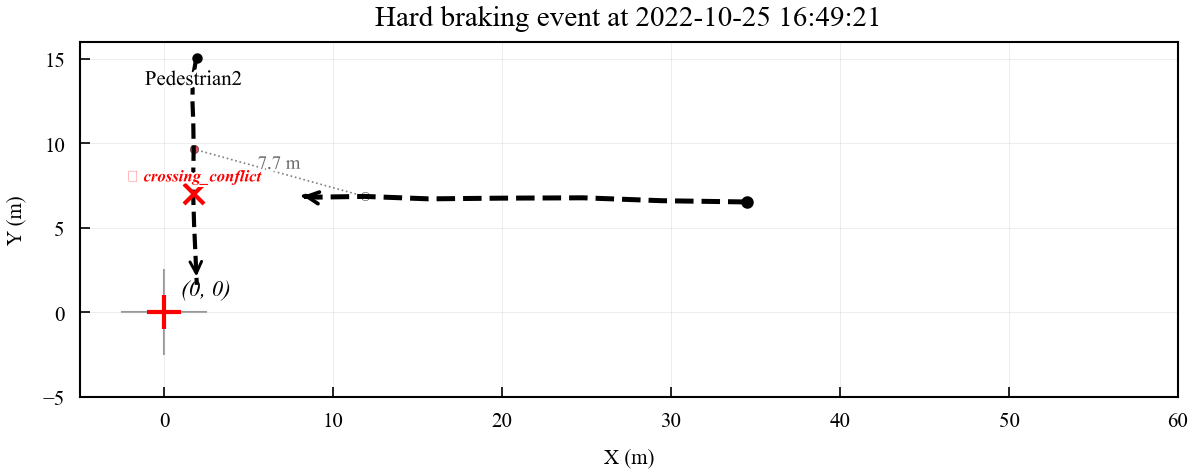

In [29]:
# cell3 
import io, contextlib

# Step 1: get report (silently)
with contextlib.redirect_stdout(io.StringIO()):
    report = analyze_anomaly(
        anomalous_event_ts='2022-10-25 16:49:21',
        shuttle_tc=shuttle_tc,
        moving_cars_tc=moving_cars_tc,
        people_tc=people_tc,
    )

# Step 2: make the plot
fig = plot_anomaly_scene_2d(
    report=report,
    shuttle_tc=shuttle_tc,
    moving_cars_tc=moving_cars_tc,
    people_tc=people_tc,
    target_agent_id=2,
    figsize=(4, 4.0),
    dpi=300)

# Step 3: add crossing angle overlay
add_crossing_overlay(fig.axes[0], report, shuttle_tc, moving_cars_tc, people_tc)

# Step 4: save
fig.savefig('79.png', dpi=400, bbox_inches='tight')
